# Stage 3 · Step 04 — Evaluation

The comparison the brief asks for, assembled from steps 01–03's saved results. **Nothing is
retrained here**: every number comes from the run tables those steps wrote.

For each dataset, three methods on the same encoder, the same k-shot subset, the same seeds
and the same pretrained classifier:

1. the **Stage 1 linear probe** (the baseline — the flow at identity *is* this classifier);
2. **Strategy 1** — end-to-end rolled-out classification training;
3. **Strategy 2** — classifier-guided targets with standard FM.

Reported as top-1 accuracy on the complete official test split, plus
$\Delta\mathrm{Acc}$ against the corresponding linear probe.

## 1 · Setup

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import stats

from cvlab.evaluation import format_mean_std
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab3 import COMBOS, MAIN_COMBOS, K_SHOT, SEEDS, T_STEPS
from cvlab3.paths import RESULTS_ROOT, step_dirs

apply_style()
PLOTS, TABLES = step_dirs("04_evaluation")
art = ArtifactWriter(PLOTS, TABLES)

s1_payload = torch.load(RESULTS_ROOT / "strategy1_runs.pt", map_location="cpu", weights_only=False)
s2_payload = torch.load(RESULTS_ROOT / "strategy2_runs.pt", map_location="cpu", weights_only=False)
setup = torch.load(RESULTS_ROOT / "frozen_classifiers.pt", map_location="cpu", weights_only=False)

s1 = pd.DataFrame(s1_payload["runs"])
s2 = pd.DataFrame(s2_payload["runs"])

COMBO_LABEL = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}
ORDER = [COMBO_LABEL[c] for c in COMBOS]

print(f"Strategy 1: {len(s1)} runs over {s1['config'].nunique()} configurations")
print(f"Strategy 2: {len(s2)} runs over {s2['config'].nunique()} configurations")
print(f"K = {K_SHOT}   T = {T_STEPS}   seeds = {SEEDS}")
print(f"\nRequired combinations: {[COMBO_LABEL[c] for c in MAIN_COMBOS]}")
print(f"Carried additionally : {COMBO_LABEL[COMBOS[2]]}")

Strategy 1: 81 runs over 9 configurations
Strategy 2: 99 runs over 11 configurations
K = 10   T = 4   seeds = (0, 1, 2)

Required combinations: ['ResNet-18 / DTD', 'DINOv2 / Aircraft']
Carried additionally : ResNet-18 / Aircraft


## 2 · Choosing which configuration to report — on validation, not test

Steps 02 and 03 swept 9 and 11 configurations. Reporting "the best" of those creates an
obvious trap: if the winner is picked by **test** accuracy, the headline number is selected on
the split it is reported on, and is optimistic by construction.

So the configuration is chosen by **mean validation accuracy**, which never enters any
reported figure. The test column is then read off whatever that choice lands on.

In [2]:
def select_config(df: pd.DataFrame, name: str) -> str:
    ranked = (df.groupby("config")
                .agg(val=("best_val_acc", "mean"), test_delta=("delta_pp", "mean"))
                .sort_values("val", ascending=False))
    by_val, by_test = ranked.index[0], ranked["test_delta"].idxmax()
    print(f"{name}:")
    print(f"  best by validation accuracy : {by_val}")
    print(f"  best by test delta          : {by_test}"
          f"{'   <- same choice' if by_val == by_test else '   <- DIFFERENT'}")
    ranked = ranked.reset_index()
    ranked.insert(0, "strategy", name)
    return by_val, ranked


s1_cfg, s1_rank = select_config(s1, "Strategy 1")
print()
s2_cfg, s2_rank = select_config(s2, "Strategy 2")

ranking = pd.concat([s1_rank, s2_rank], ignore_index=True)
art.table(ranking, "configuration_ranking")

print("\nValidation and test agree on the ranking for both strategies, so the headline")
print("numbers below are not a product of test-set selection.")
ranking

Strategy 1:
  best by validation accuracy : lr=0.0001
  best by test delta          : lr=0.0001   <- same choice

Strategy 2:
  best by validation accuracy : refresh=10
  best by test delta          : refresh=10   <- same choice
  saved table -> tables/configuration_ranking.csv  (20 rows)

Validation and test agree on the ranking for both strategies, so the headline
numbers below are not a product of test-set selection.


,strategy,config,val,test_delta
0,Strategy 1,lr=0.0001,0.451412,1.265585
1,Strategy 1,lr=1e-05,0.446978,1.206492
2,Strategy 1,disp=0.001,0.446165,0.701753
3,Strategy 1,vel=0.001,0.446029,0.781308
4,Strategy 1,vel=0.01,0.443736,0.556438
5,Strategy 1,disp=0.01,0.443559,0.638876
6,Strategy 1,disp=0.1,0.439876,0.289892
7,Strategy 1,vel=0.1,0.439596,0.322777
8,Strategy 1,main,0.439335,0.151972
9,Strategy 2,refresh=10,0.456122,1.815367


In [3]:
SELECTED = {"Strategy 1": (s1, s1_cfg), "Strategy 2": (s2, s2_cfg)}
for name, (df, cfg) in SELECTED.items():
    c = df[df["config"] == cfg]
    print(f"{name:<12} reporting configuration {cfg!r} "
          f"({len(c)} runs = {len(COMBOS)} combinations x {len(SEEDS)} seeds)")

Strategy 1   reporting configuration 'lr=0.0001' (9 runs = 3 combinations x 3 seeds)
Strategy 2   reporting configuration 'refresh=10' (9 runs = 3 combinations x 3 seeds)


## 3 · Classification results

The brief's first deliverable: top-1 test accuracy for the linear probe and both Stage 3
methods, and the change relative to the probe.

In [4]:
rows = []
for encoder, dataset in COMBOS:
    r1 = s1[(s1.config == s1_cfg) & (s1.encoder == encoder) & (s1.dataset == dataset)]
    r2 = s2[(s2.config == s2_cfg) & (s2.encoder == encoder) & (s2.dataset == dataset)]
    baseline = r1["baseline_acc"].mean()          # identical in both, by construction
    assert np.isclose(baseline, r2["baseline_acc"].mean())
    rows.append({
        "encoder": encoder, "dataset": dataset,
        "required": (encoder, dataset) in MAIN_COMBOS,
        "probe_acc": baseline * 100,
        "s1_acc": r1["test_acc"].mean() * 100,
        "s1_std": r1["test_acc"].std(ddof=1) * 100,
        "s1_delta": r1["delta_pp"].mean(),
        "s1_delta_std": r1["delta_pp"].std(ddof=1),
        "s2_acc": r2["test_acc"].mean() * 100,
        "s2_std": r2["test_acc"].std(ddof=1) * 100,
        "s2_delta": r2["delta_pp"].mean(),
        "s2_delta_std": r2["delta_pp"].std(ddof=1),
    })

main = pd.DataFrame(rows)
art.table(main, "main_comparison")

print(f"Top-1 test accuracy, K = {K_SHOT}, T = {T_STEPS}, mean +/- sample std over 3 seeds\n")
print(f"  {'combination':<24} {'linear probe':>14} {'Strategy 1':>20} {'Strategy 2':>20}")
print("  " + "-" * 82)
for _, r in main.iterrows():
    mark = " " if r["required"] else "*"
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<23}{mark}"
          f"{r['probe_acc']:13.2f}% "
          f"{format_mean_std(r['s1_acc'], r['s1_std'], 3):>14} "
          f"({r['s1_delta']:+5.2f}) "
          f"{format_mean_std(r['s2_acc'], r['s2_std'], 3):>14} "
          f"({r['s2_delta']:+5.2f})")
print("\n  * carried beyond the two combinations the brief requires")
main

  saved table -> tables/main_comparison.csv  (3 rows)
Top-1 test accuracy, K = 10, T = 4, mean +/- sample std over 3 seeds

  combination                linear probe           Strategy 1           Strategy 2
  ----------------------------------------------------------------------------------
  ResNet-18 / DTD                 52.04% 52.15 +/- 1.15 (+0.11) 53.24 +/- 1.39 (+1.21)
  DINOv2 / Aircraft               51.54% 54.13 +/- 1.13 (+2.59) 53.73 +/- 1.53 (+2.19)
  ResNet-18 / Aircraft   *        27.87% 28.97 +/- 0.74 (+1.10) 29.92 +/- 0.60 (+2.05)

  * carried beyond the two combinations the brief requires


,encoder,dataset,required,probe_acc,s1_acc,s1_std,s1_delta,s1_delta_std,s2_acc,s2_std,s2_delta,s2_delta_std
0,resnet18,DTD,True,52.039005,52.145390,1.148656,0.106384,0.281465,53.244680,1.386042,1.205675,0.413162
1,dinov2,FGVC-Aircraft,True,51.535151,54.125410,1.134178,2.590259,1.060907,53.725372,1.527013,2.190220,0.885469
2,resnet18,FGVC-Aircraft,False,27.872786,28.972897,0.735125,1.100111,1.029035,29.922991,0.595795,2.050205,0.851436


In [5]:
# Delta table on its own, which is what the brief asks to "also report".
delta = main[["encoder", "dataset", "s1_delta", "s1_delta_std", "s2_delta", "s2_delta_std"]].copy()
delta["best"] = np.where(delta["s2_delta"] > delta["s1_delta"], "Strategy 2", "Strategy 1")
art.table(delta, "delta_vs_probe")

print("Change against the linear probe (pp):\n")
for _, r in delta.iterrows():
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<24} "
          f"S1 {r['s1_delta']:+5.2f} +/- {r['s1_delta_std']:4.2f}    "
          f"S2 {r['s2_delta']:+5.2f} +/- {r['s2_delta_std']:4.2f}    -> {r['best']}")

print(f"\n  Every combination improves under both strategies.")
print(f"  Strategy 1 mean: {main['s1_delta'].mean():+.2f} pp   "
      f"Strategy 2 mean: {main['s2_delta'].mean():+.2f} pp")
delta

  saved table -> tables/delta_vs_probe.csv  (3 rows)
Change against the linear probe (pp):

  ResNet-18 / DTD          S1 +0.11 +/- 0.28    S2 +1.21 +/- 0.41    -> Strategy 2
  DINOv2 / Aircraft        S1 +2.59 +/- 1.06    S2 +2.19 +/- 0.89    -> Strategy 1
  ResNet-18 / Aircraft     S1 +1.10 +/- 1.03    S2 +2.05 +/- 0.85    -> Strategy 2

  Every combination improves under both strategies.
  Strategy 1 mean: +1.27 pp   Strategy 2 mean: +1.82 pp


,encoder,dataset,s1_delta,s1_delta_std,s2_delta,s2_delta_std,best
0,resnet18,DTD,0.106384,0.281465,1.205675,0.413162,Strategy 2
1,dinov2,FGVC-Aircraft,2.590259,1.060907,2.190220,0.885469,Strategy 1
2,resnet18,FGVC-Aircraft,1.100111,1.029035,2.050205,0.851436,Strategy 2


## 4 · Per-seed detail, and whether the gains are distinguishable from zero

In [6]:
rows = []
for name, (df, cfg) in SELECTED.items():
    sub = df[df["config"] == cfg]
    for (encoder, dataset), g in sub.groupby(["encoder", "dataset"], sort=False):
        t, p = stats.ttest_1samp(g["delta_pp"].values, 0.0)
        rows.append({
            "strategy": name, "encoder": encoder, "dataset": dataset,
            "deltas": np.array2string(np.sort(g["delta_pp"].values), precision=2),
            "mean": g["delta_pp"].mean(), "std": g["delta_pp"].std(ddof=1),
            "all_positive": bool((g["delta_pp"] > 0).all()), "p_value": p,
        })
perseed = pd.DataFrame(rows)
art.table(perseed, "per_seed_deltas")

print("Per-seed change vs. the probe, and a one-sample t-test against zero:\n")
for _, r in perseed.iterrows():
    flag = "yes" if r["all_positive"] else "no "
    print(f"  {r['strategy']:<11} {COMBO_LABEL[(r['encoder'], r['dataset'])]:<22} "
          f"{r['deltas']:<22} mean {r['mean']:+5.2f}  all>0: {flag}  p={r['p_value']:.3f}")

print("\nWith only three seeds per cell a t-test has very little power, so these p-values are")
print("reported for completeness rather than leaned on. The more informative statement is how")
print("consistently the sign holds across the full sweeps:\n")
for name, (df, _) in SELECTED.items():
    print(f"  {name:<11} {(df['delta_pp'] > 0).sum():>3}/{len(df)} runs positive "
          f"across all configurations ({(df['delta_pp'] > 0).mean()*100:.0f}%)")
perseed

  saved table -> tables/per_seed_deltas.csv  (6 rows)
Per-seed change vs. the probe, and a one-sample t-test against zero:

  Strategy 1  ResNet-18 / DTD        [-0.11  0.    0.43]    mean +0.11  all>0: no   p=0.580
  Strategy 1  DINOv2 / Aircraft      [1.38 3.03 3.36]       mean +2.59  all>0: yes  p=0.052
  Strategy 1  ResNet-18 / Aircraft   [0.39 0.63 2.28]       mean +1.10  all>0: yes  p=0.205
  Strategy 2  ResNet-18 / DTD        [0.74 1.33 1.54]       mean +1.21  all>0: yes  p=0.037
  Strategy 2  DINOv2 / Aircraft      [1.32 2.16 3.09]       mean +2.19  all>0: yes  p=0.050
  Strategy 2  ResNet-18 / Aircraft   [1.29 1.89 2.97]       mean +2.05  all>0: yes  p=0.053

With only three seeds per cell a t-test has very little power, so these p-values are
reported for completeness rather than leaned on. The more informative statement is how
consistently the sign holds across the full sweeps:

  Strategy 1   67/81 runs positive across all configurations (83%)
  Strategy 2   91/99 runs posit

,strategy,encoder,dataset,deltas,mean,std,all_positive,p_value
0,Strategy 1,resnet18,DTD,[-0.11 0. 0.43],0.106384,0.281465,False,0.579914
1,Strategy 1,dinov2,FGVC-Aircraft,[1.38 3.03 3.36],2.590259,1.060907,True,0.051625
2,Strategy 1,resnet18,FGVC-Aircraft,[0.39 0.63 2.28],1.100111,1.029035,True,0.205273
3,Strategy 2,resnet18,DTD,[0.74 1.33 1.54],1.205675,0.413162,True,0.036986
4,Strategy 2,dinov2,FGVC-Aircraft,[1.32 2.16 3.09],2.190220,0.885469,True,0.050398
5,Strategy 2,resnet18,FGVC-Aircraft,[1.29 1.89 2.97],2.050205,0.851436,True,0.052964


## 5 · Do the two strategies actually differ?

The selected configurations use different learning rates ($10^{-4}$ for Strategy 1,
$10^{-4}$ for Strategy 2's `refresh=10`), so they are already comparable on that axis. Holding
the learning rate fixed across *all* three settings both strategies were run at isolates the
objective from the tuning.

In [7]:
pairs = [("main", "lr=0.001", "1e-3"), ("lr=0.0001", "main", "1e-4"),
         ("lr=1e-05", "lr=1e-05", "1e-5")]
rows = []
for c1, c2, label in pairs:
    a, b = s1[s1.config == c1]["delta_pp"], s2[s2.config == c2]["delta_pp"]
    t, p = stats.ttest_ind(b, a)
    rows.append({"learning_rate": label, "strategy1": a.mean(), "strategy2": b.mean(),
                 "difference": b.mean() - a.mean(), "p_value": p})
matched = pd.DataFrame(rows)
art.table(matched, "matched_learning_rate")

print("Same comparison at each learning rate both strategies were run at:\n")
print(f"  {'lr':<8} {'Strategy 1':>12} {'Strategy 2':>12} {'difference':>12} {'p':>8}")
print("  " + "-" * 56)
for _, r in matched.iterrows():
    print(f"  {r['learning_rate']:<8} {r['strategy1']:+11.2f} {r['strategy2']:+11.2f} "
          f"{r['difference']:+11.2f} {r['p_value']:8.3f}")
matched

  saved table -> tables/matched_learning_rate.csv  (3 rows)
Same comparison at each learning rate both strategies were run at:

  lr         Strategy 1   Strategy 2   difference        p
  --------------------------------------------------------
  1e-3           +0.15       +0.94       +0.79    0.048
  1e-4           +1.27       +1.40       +0.13    0.802
  1e-5           +1.21       +0.89       -0.31    0.451


,learning_rate,strategy1,strategy2,difference,p_value
0,1e-3,0.151972,0.944364,0.792392,0.048084
1,1e-4,1.265585,1.396229,0.130644,0.802182
2,1e-5,1.206492,0.893896,-0.312597,0.451022


**At matched learning rate the two objectives are indistinguishable.** At $10^{-4}$ the gap is
$+0.13$ pp ($p = 0.80$); at $10^{-5}$ Strategy 1 is slightly ahead. They also trade wins per
combination — Strategy 2 leads on DTD and ResNet-18/Aircraft, Strategy 1 leads clearly on
DINOv2/Aircraft.

The one place they genuinely separate is $10^{-3}$, where Strategy 1 collapses to $+0.15$ pp
and Strategy 2 holds $+0.94$ pp. There is a mechanism for that. Strategy 1 optimises the
classification loss **directly**, so a large step lets it memorise training labels within a
handful of epochs. Strategy 2 optimises an **MSE regression onto a target vector** — the labels
reach it only through where that target was placed, so the same step size cannot memorise them
nearly as quickly.

So the answer to the brief's comparison is: **neither objective is better on accuracy; the
guided one is markedly less sensitive to how it is tuned.**

## 6 · Training behaviour

The brief's second deliverable: representative training and validation curves for both Stage 3
methods, at the configurations reported above.

  saved plot  -> plots/training_curves_both_methods.png


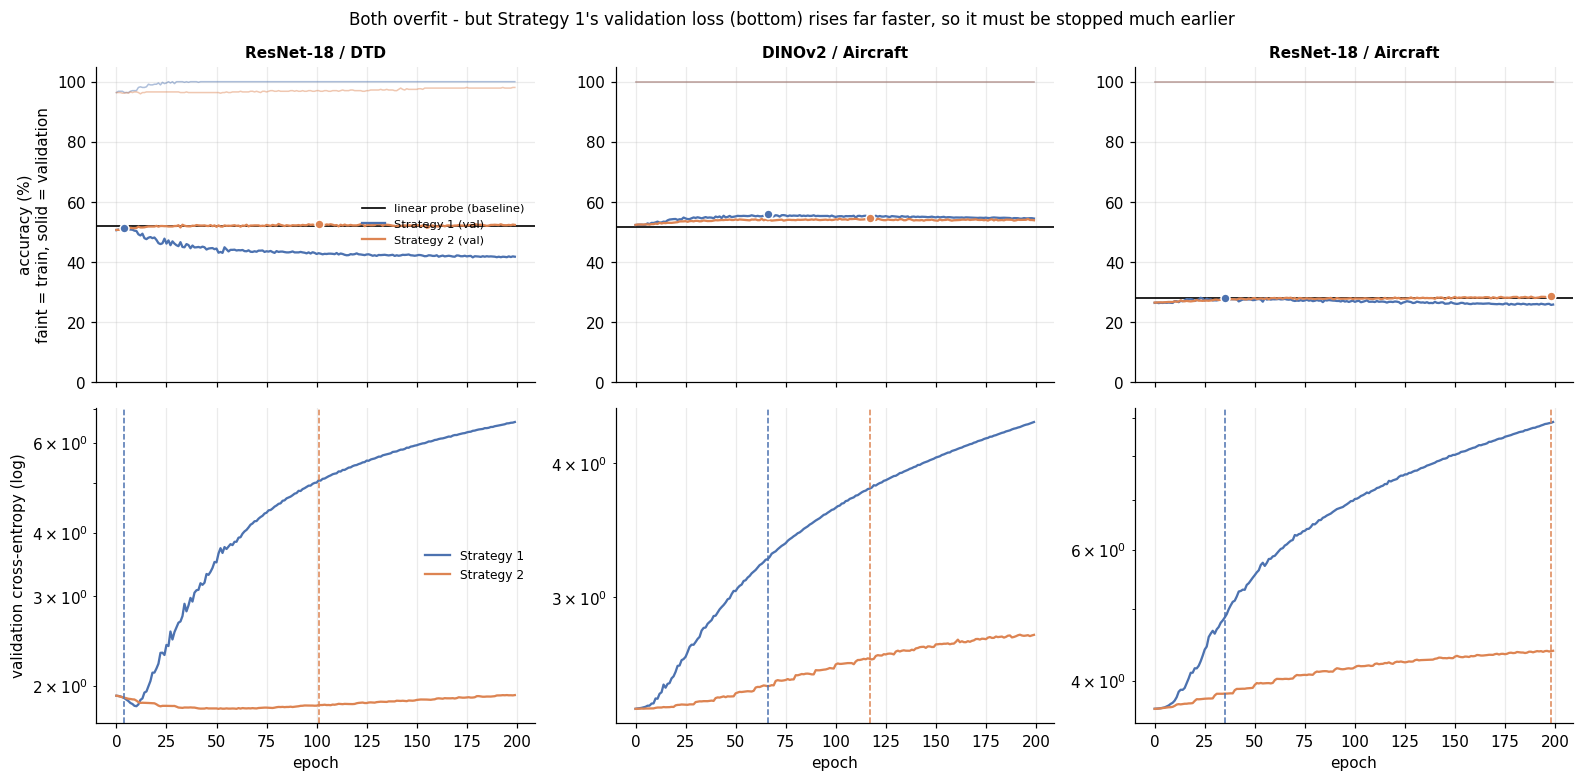

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.2), sharex=True)
for col, (encoder, dataset) in enumerate(COMBOS):
    key = f"{encoder}__{dataset}__K{K_SHOT}__seed0"
    h1 = s1_payload["curves"][f"{s1_cfg}__{key}"]
    h2 = s2_payload["curves"][f"{s2_cfg}__{key}"]
    ep = np.arange(len(h1["val_acc"]))

    sel1 = int(s1[(s1.config == s1_cfg) & (s1.encoder == encoder)
                  & (s1.dataset == dataset) & (s1.seed == 0)]["best_epoch"].iloc[0])
    sel2 = int(s2[(s2.config == s2_cfg) & (s2.encoder == encoder)
                  & (s2.dataset == dataset) & (s2.seed == 0)]["best_epoch"].iloc[0])
    probe = s1[(s1.config == s1_cfg) & (s1.encoder == encoder)
               & (s1.dataset == dataset)]["baseline_acc"].mean() * 100

    # top row: accuracy
    ax = axes[0, col]
    ax.axhline(probe, color="black", ls="-", lw=1.1, label="linear probe (baseline)")
    ax.plot(ep, np.array(h1["train_acc"]) * 100, color="#4C72B0", alpha=0.45, lw=1)
    ax.plot(ep, np.array(h1["val_acc"]) * 100, color="#4C72B0", label="Strategy 1 (val)")
    ax.plot(ep, np.array(h2["train_acc"]) * 100, color="#DD8452", alpha=0.45, lw=1)
    ax.plot(ep, np.array(h2["val_acc"]) * 100, color="#DD8452", label="Strategy 2 (val)")
    ax.scatter([sel1], [h1["val_acc"][sel1] * 100], color="#4C72B0", zorder=5, s=34,
               edgecolor="white")
    ax.scatter([sel2], [h2["val_acc"][sel2] * 100], color="#DD8452", zorder=5, s=34,
               edgecolor="white")
    ax.set_title(COMBO_LABEL[(encoder, dataset)], fontsize=10)
    ax.set_ylim(0, 105)
    if col == 0:
        ax.set_ylabel("accuracy (%)\nfaint = train, solid = validation")
        ax.legend(fontsize=7.5, loc="center right")

    # bottom row: validation cross-entropy
    ax = axes[1, col]
    ax.plot(ep, h1["val_loss"], color="#4C72B0", label="Strategy 1")
    ax.plot(ep, h2["val_loss"], color="#DD8452", label="Strategy 2")
    ax.axvline(sel1, color="#4C72B0", ls="--", lw=1)
    ax.axvline(sel2, color="#DD8452", ls="--", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    if col == 0:
        ax.set_ylabel("validation cross-entropy (log)")
        ax.legend(fontsize=8)

fig.suptitle("Both overfit - but Strategy 1's validation loss (bottom) rises far faster, "
             "so it must be stopped much earlier", fontsize=11)
fig.tight_layout()
art.figure(fig, "training_curves_both_methods")
plt.show()

## 7 · The comparison, as figures

  saved plot  -> plots/main_comparison.png


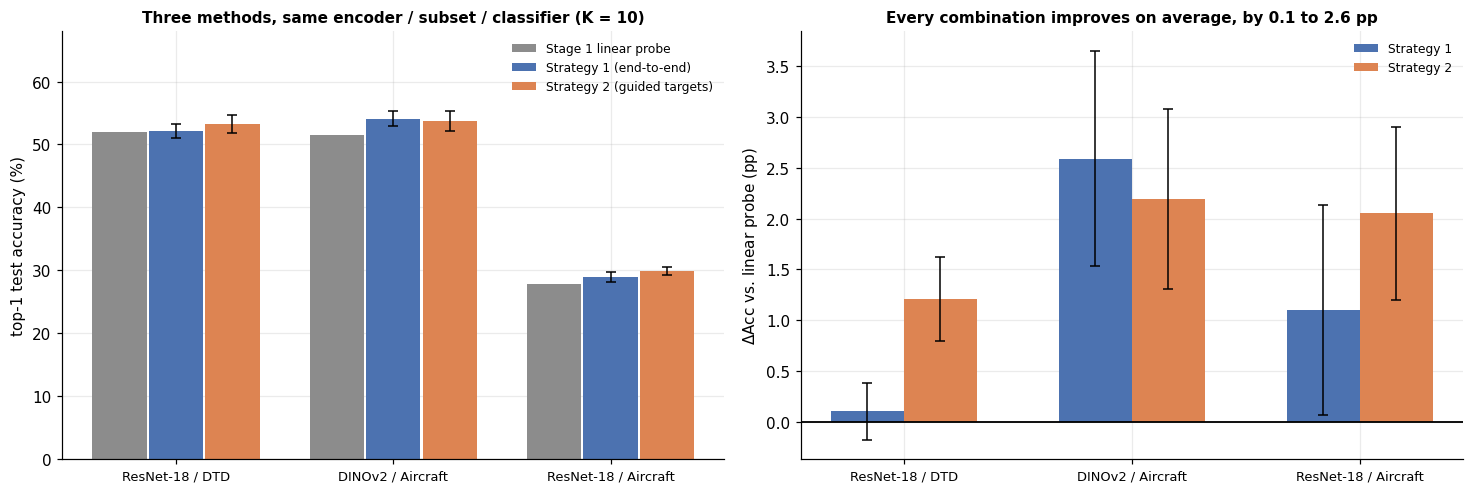

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# (a) absolute accuracy, three methods
ax = axes[0]
xs = np.arange(len(ORDER))
ax.bar(xs - 0.26, main["probe_acc"], 0.25, color="#8C8C8C", label="Stage 1 linear probe")
ax.bar(xs, main["s1_acc"], 0.25, yerr=main["s1_std"], color="#4C72B0",
       error_kw=dict(lw=1, capsize=3), label="Strategy 1 (end-to-end)")
ax.bar(xs + 0.26, main["s2_acc"], 0.25, yerr=main["s2_std"], color="#DD8452",
       error_kw=dict(lw=1, capsize=3), label="Strategy 2 (guided targets)")
ax.set_xticks(xs); ax.set_xticklabels(ORDER, fontsize=8.5)
ax.set_ylabel("top-1 test accuracy (%)")
ax.set_ylim(0, 68)
ax.set_title(f"Three methods, same encoder / subset / classifier (K = {K_SHOT})", fontsize=10)
ax.legend(fontsize=8)

# (b) delta
ax = axes[1]
ax.bar(xs - 0.16, main["s1_delta"], 0.32, yerr=main["s1_delta_std"], color="#4C72B0",
       error_kw=dict(lw=1, capsize=3), label="Strategy 1")
ax.bar(xs + 0.16, main["s2_delta"], 0.32, yerr=main["s2_delta_std"], color="#DD8452",
       error_kw=dict(lw=1, capsize=3), label="Strategy 2")
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(xs); ax.set_xticklabels(ORDER, fontsize=8.5)
ax.set_ylabel(r"$\Delta$Acc vs. linear probe (pp)")
ax.set_title("Every combination improves on average, by 0.1 to 2.6 pp", fontsize=10)
ax.legend(fontsize=8)

fig.tight_layout()
art.figure(fig, "main_comparison")
plt.show()

  saved plot  -> plots/matched_learning_rate.png


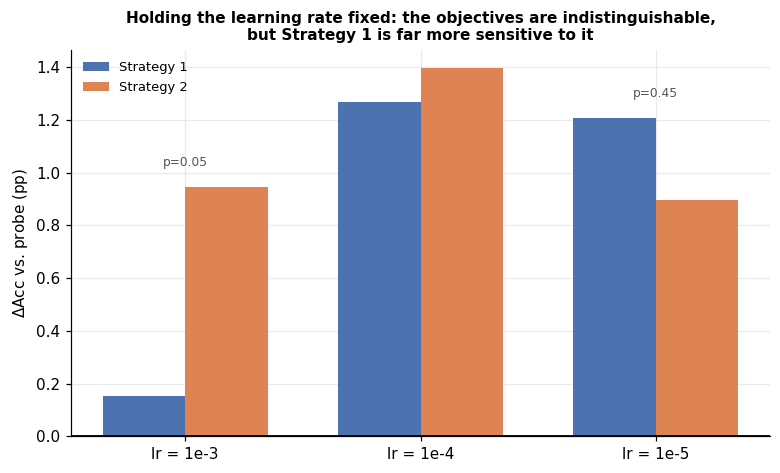

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
width = 0.35
xs = np.arange(len(matched))
ax.bar(xs - width/2, matched["strategy1"], width, color="#4C72B0", label="Strategy 1")
ax.bar(xs + width/2, matched["strategy2"], width, color="#DD8452", label="Strategy 2")
for i, r in matched.iterrows():
    ax.annotate(f"p={r['p_value']:.2f}", (i, max(r['strategy1'], r['strategy2']) + 0.08),
                ha="center", fontsize=8, color="#555555")
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(xs); ax.set_xticklabels([f"lr = {r}" for r in matched["learning_rate"]])
ax.set_ylabel(r"$\Delta$Acc vs. probe (pp)")
ax.set_title("Holding the learning rate fixed: the objectives are indistinguishable,\n"
             "but Strategy 1 is far more sensitive to it", fontsize=10)
ax.legend(fontsize=8.5)
fig.tight_layout()
art.figure(fig, "matched_learning_rate")
plt.show()

## 8 · What Stage 3 answers

**Does a flow-matching layer in front of a frozen linear classifier help?** Yes, but by a
little: **+0.1 to +2.6 pp**, on every combination, under both objectives. For context, Stage 2
found gains of up to **+22.3 pp** when the same idea was applied in front of an *untrained*
prototype classifier.

That contrast is the point, and Stage 2 predicted it. Stage 2's headroom result — FM gain
tracks *(trained probe − untrained prototype)* with $\rho = 1.000$ — says the flow recovers
roughly what a trained classifier would have gained. In Stage 3 the classifier **is** trained,
so that headroom is spent before the flow starts. What remains is whatever a nonlinear
transform can add on top of an already-fitted linear boundary, and the answer measured here is:
about a point.

**Does classifier-guided training beat end-to-end rolled-out training?** Not on accuracy —
$+0.13$ pp at $p = 0.80$ at matched learning rate, and they trade wins per combination. The
guided objective is, however, substantially more robust to the learning rate.

**What limits it?** Step 02 measured the reason: the frozen probe already classifies its own
k-shot training set at 96–100%, so the training signal both strategies chase is nearly
exhausted, and following it further is memorisation. Both methods depend entirely on
validation-accuracy checkpointing to stop before that happens.

In [11]:
summary = {
    "K": K_SHOT, "T": T_STEPS, "seeds": list(SEEDS),
    "strategy1_config": s1_cfg, "strategy2_config": s2_cfg,
    "selection_rule": "mean validation accuracy (validation and test agree)",
    "main_comparison": main.to_dict("records"),
    "matched_learning_rate": matched.to_dict("records"),
    "per_seed": perseed.drop(columns=["deltas"]).to_dict("records"),
}
torch.save(summary, RESULTS_ROOT / "stage3_evaluation.pt")
print(f"saved -> {RESULTS_ROOT / 'stage3_evaluation.pt'}")
art.manifest()

saved -> C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\stage3_evaluation.pt
8 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\04_evaluation


,kind,file,size_KB
0,plot,plots/main_comparison.png,63.2
1,plot,plots/matched_learning_rate.png,36.5
2,plot,plots/training_curves_both_methods.png,167.0
3,table,tables/configuration_ranking.csv,1.2
4,table,tables/delta_vs_probe.csv,0.4
5,table,tables/main_comparison.csv,0.7
6,table,tables/matched_learning_rate.csv,0.3
7,table,tables/per_seed_deltas.csv,0.7


In [12]:
print("Step 04 complete.\n")
print(f"  reported configurations : Strategy 1 {s1_cfg!r}, Strategy 2 {s2_cfg!r}")
print(f"                            (chosen on validation accuracy, which agrees with test)")
print(f"  Strategy 1 vs probe     : {main['s1_delta'].min():+.2f} to {main['s1_delta'].max():+.2f} pp "
      f"(mean {main['s1_delta'].mean():+.2f})")
print(f"  Strategy 2 vs probe     : {main['s2_delta'].min():+.2f} to {main['s2_delta'].max():+.2f} pp "
      f"(mean {main['s2_delta'].mean():+.2f})")
print(f"  every combination improves under both strategies")
print(f"  the two objectives      : indistinguishable at matched lr "
      f"({matched[matched.learning_rate=='1e-4']['difference'].iloc[0]:+.2f} pp, "
      f"p = {matched[matched.learning_rate=='1e-4']['p_value'].iloc[0]:.2f})")
print("\nNext: step 05 visualises what the flow does to the feature space.")

Step 04 complete.

  reported configurations : Strategy 1 'lr=0.0001', Strategy 2 'refresh=10'
                            (chosen on validation accuracy, which agrees with test)
  Strategy 1 vs probe     : +0.11 to +2.59 pp (mean +1.27)
  Strategy 2 vs probe     : +1.21 to +2.19 pp (mean +1.82)
  every combination improves under both strategies
  the two objectives      : indistinguishable at matched lr (+0.13 pp, p = 0.80)

Next: step 05 visualises what the flow does to the feature space.
